<a href="https://colab.research.google.com/github/nadynstary/DSI-machine-learning-model/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9303 - loss: 0.2375 - val_accuracy: 0.9594 - val_loss: 0.1298
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9689 - loss: 0.1014 - val_accuracy: 0.9705 - val_loss: 0.0940
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9777 - loss: 0.0707 - val_accuracy: 0.9711 - val_loss: 0.0944
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9826 - loss: 0.0549 - val_accuracy: 0.9759 - val_loss: 0.0784
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9852 - loss: 0.0444 - val_accuracy: 0.9769 - val_loss: 0.0784
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0784
Test accuracy: 0.9768999814987183
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
image 0 : predicted=7, True=7
image 1 : predicted=2, True=2
image 2 : predicted=1, True=1
image 3 : predicted=0, True=0
image 4 : predicted=4, True=4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


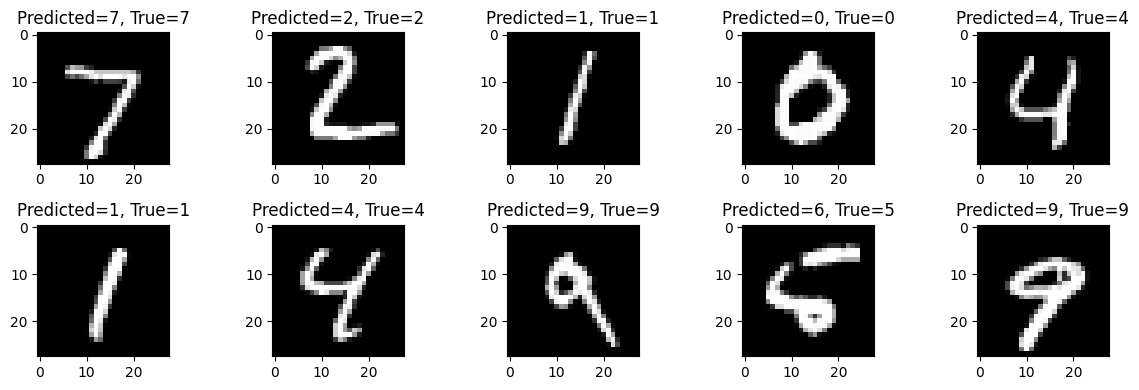

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models


mnist= tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test)= mnist.load_data()
x_train, x_test= x_train/255.0, x_test/255.0
x_train_flat= x_train.reshape(-1, 28*28)
x_test_flat= x_test.reshape(-1, 28*28)

model=models.Sequential([
    layers.Dense(128, activation='relu',input_shape=(28*28,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train_flat, y_train, epochs=5, validation_data=(x_test_flat, y_test))
test_loss, test_acc=model.evaluate(x_test_flat, y_test)
print('Test accuracy:', test_acc)
predictions= model.predict(x_test_flat[:5])
for i, pred in enumerate(predictions):
  print(f"image {i} : predicted={pred.argmax()}, True={y_test[i]}")

predicitions = model.predict(x_test_flat[:10])
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i], cmap='gray')
  plt.title(f"Predicted={predicitions[i].argmax()}, True={y_test[i]}")
  plt.axiz=('off')
plt.tight_layout()
plt.show()
